In [1]:
import numpy as np
import matplotlib.pyplot as plt

# lets me import from a different directory
import sys 
sys.path.append("/Users/archie/documents/year4/project/code")

import spin_tools.hamiltonians as hamiltonians
from spin_tools.gates import *
import spin_tools.quantum_tools as qt
from spin_tools.floquet_tools import ccd_floquet

0.011214563911536874


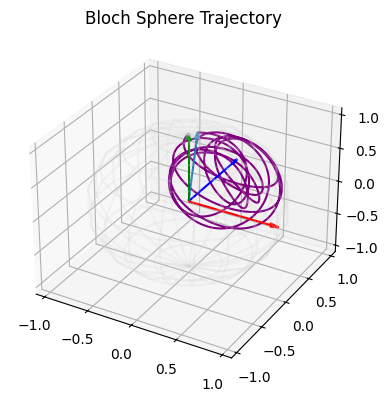

In [25]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005


# CCD parameters
phi_0, epsilon_m, phase_freq, theta_m = 0, rabi_freq/4, rabi_freq, 0


# Integration parameters
tol = 10**-12
evaluation_points = 2000
evaluation_time = 4/rabi_freq

detuning = 0.01

times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa,
                            driving_freq=driving_freq,
                            natural_freq=natural_freq-detuning, 
                            rabi_freq=rabi_freq, 
                            phi_0=phi_0,
                            epsilon_m=epsilon_m,
                            phase_freq=phase_freq,
                            theta_m=theta_m,
                            atol=tol,
                            rtol=tol)
ccd_floquet_freq = np.sign(detuning)*2*ccd_floquet(natural_freq-detuning, driving_freq, rabi_freq, phi_0, epsilon_m, phase_freq, theta_m)[4]
print(ccd_floquet_freq)
floq_Us = qt.phase_boost_unitaries(Us_driving_frame, detuning+0.0011, times)

times, Us_error_channels = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa_error_channels,
                            driving_freq=driving_freq,
                            natural_freq=natural_freq-detuning, 
                            rabi_freq=rabi_freq, 
                            phi_0=phi_0,
                            epsilon_m=epsilon_m,
                            phase_freq=phase_freq,
                            theta_m=theta_m,
                            atol=tol,
                            rtol=tol)

initial_state = np.array([1+0j,0+0j])

states = []
for U in floq_Us:
    states.append(U @ initial_state)

states = np.array(states)

qt.visualise_solution(times, states)

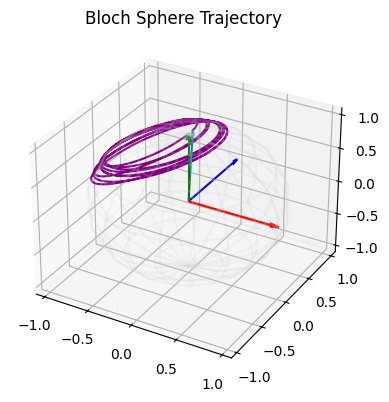

In [6]:
states_error_channels = []
for U in Us_error_channels:
    states_error_channels.append(U @ initial_state)

states_error_channels = np.array(states_error_channels)

qt.visualise_solution(times, states_error_channels)